## Getting started
In order to get started, create a virtual environment via conda:

```conda create --file environment.yml```

Then select the newly created virtual environemnt for the notebook's kernel

In [481]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Preprocessing
This preprocessing step aims to:
- Load raw data as a dataframe
- Plot time series features
- Trim first and last 10 seconds of each recording
- Synchronize dataframe into uniform 100 samples per second grid
- Stores preprocessed files in data/processed

**Load raw data**

In [482]:
# TODO Implement load_data function here, returns dataframe
import pandas as pd
import matplotlib.pyplot as plt
def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)

filepath = 'data/raw/bumpy/2026-09-12_14-09-10/Accelerometer.csv' # insert filepath here
df = load_data(filepath) # load as dataframe

print(df.columns)
df.head()

Index(['time', 'seconds_elapsed', 'z', 'y', 'x'], dtype='str')


,time,seconds_elapsed,z,y,x
0,1789222150095785000,0.054785,12.642402,2.111705,-1.935764
1,1789222150105779000,0.064779,1.998088,2.568794,-1.115979
2,1789222150115774000,0.074774,-13.362187,-4.826614,0.764603
3,1789222150125768000,0.084768,-3.974676,-0.177178,0.352524
4,1789222150135762000,0.094762,4.010883,1.920324,-0.098737


**Plotting function**

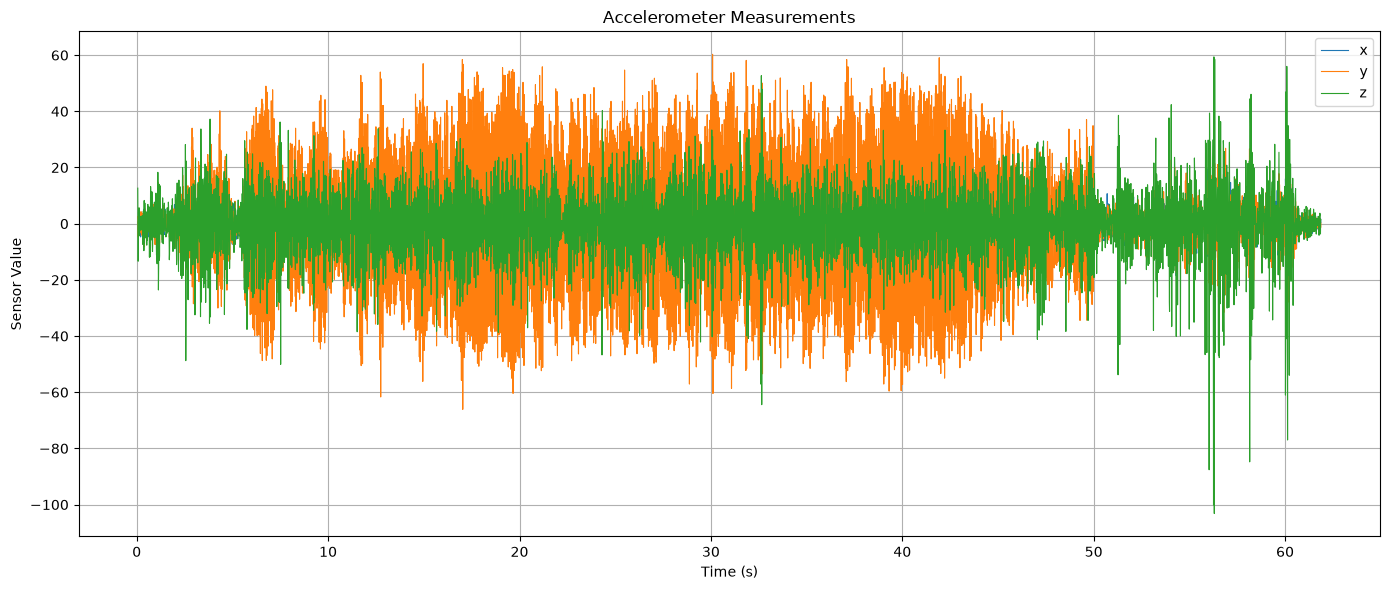

In [483]:
# TODO Implement plotting function here
def plot_features(df: pd.DataFrame):

    plt.figure(figsize=(14,6))

    for axis in ['x', 'y', 'z']:
        plt.plot(df['seconds_elapsed'], df[axis], label=axis, linewidth=0.8)

    plt.xlabel('Time (s)')
    plt.ylabel('Sensor Value')
    plt.title('Accelerometer Measurements')

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()
plot_features(df)

Index(['time', 'seconds_elapsed', 'z', 'y', 'x'], dtype='str')


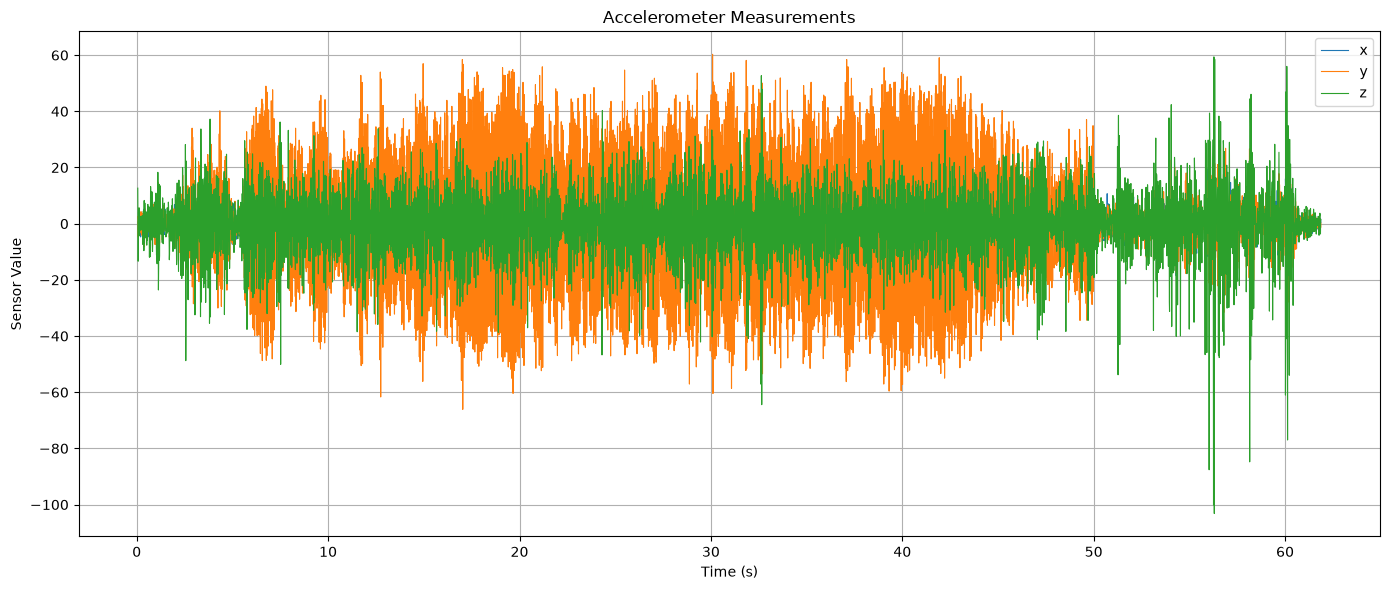

In [484]:
filepath = 'data/raw/bumpy/2026-09-12_14-09-10/Accelerometer.csv'

df = load_data(filepath)

print(df.columns)

plot_features(df)

**Trimming function**

In [485]:
def trim_data(df: pd.DataFrame, limit=10):
    """
    Trim the first and last `limit` seconds of a dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Raw sensor dataframe containing a 'seconds_elapsed' column.
    limit : int or float, default=10
        Number of seconds to remove from the beginning and end.

    Returns
    -------
    pd.DataFrame
        Trimmed dataframe.
    """
    if limit < 0:
        raise ValueError("limit must be non-negative")

    if df.empty:
        return df.copy()

    start_time = df["seconds_elapsed"].iloc[0] + limit
    end_time = df["seconds_elapsed"].iloc[-1] - limit

    return df[
        (df["seconds_elapsed"] >= start_time)
        & (df["seconds_elapsed"] <= end_time)
    ].copy()

**Synchronization**

In [486]:
SAMPLING_FREQUENCY = 100
def synchronize_data(df: pd.DataFrame, fs=SAMPLING_FREQUENCY) -> pd.DataFrame:
    """
    Performs interpolation between data points such that the data seconds_elapsed are uniform.

    :param df: dataframe to synchronize
    :param fs: sampling frequency, sets the number of points per second
    :return: synced dataframe with uniform grid
    """
    # Set index and drop time column
    df = df.drop(columns='time', errors='ignore').set_index("seconds_elapsed")

    # Decrement seconds_elapsed by the minimum
    df.index = df.index - df.index.min()
    
    # Prepare grid
    n = int(np.floor(df.index.max() * fs)) + 1 # Number of points
    grid_index = pd.Index(np.arange(n) / fs, name='seconds_elapsed')


    # Create a temporary union for the index to include the grid index
    combined_index = df.index.union(grid_index)

    # Perform interpolation
    df_sync = (
        df.reindex(combined_index)
        .interpolate(method='index')
        .reindex(grid_index)
    )
    return df_sync

**Proprocess a single file**

In [487]:
def preprocess(filepath: str) -> pd.DataFrame:
    """
    Runs the full preprocessing pipeline given a filepath
    
    :param filepath: path to measurement file
    """
    df = load_data(filepath)
    df = trim_data(df)
    df = synchronize_data(df)

    return df

**Running the preprocessing pipeline on the whole raw data directory**

In [488]:
import os
import shutil

TARGET_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv", "Metadata.csv"]

def preprocess_files(src_root: str, out_root: str):
    """
    Runs the preprocessing pipeline on a given source directory

    :param src_root: Source directory of raw data files
    :param out_root: Target directory of processed files
    """

    for dirpath, dirnames, filenames in os.walk(src_root):
            
        # List all files in this path
        for file in filenames:

          
            # Skip non target files
            if file not in TARGET_FILES:
                continue

            fpath = os.path.join(dirpath, file)

            # Mirror the raw folder structure under data/processed
            outpath = os.path.join(out_root, os.path.relpath(fpath, src_root))
            os.makedirs(os.path.dirname(outpath), exist_ok=True)
            
            # Copy Metadata file
            if file == 'Metadata.csv':
                shutil.copy(fpath, outpath)
                continue

            df_processed = preprocess(fpath)
            df_processed.to_csv(outpath)

src_root = os.path.join('data', 'raw')
out_root = os.path.join('data', 'processed')
preprocess_files(src_root, out_root)


**Data Visualization and Data Understanding**

With trimmed and synchronized recordings stored under `data/processed/`, we
inspect the signals before extracting features. Rather than pooling all
recordings, we plot them **grouped by device**, since the three phones were
each carried by a different rider, which could suggest variations in the bike itself (different bikes have different damping), how the rider cycles and differences in sensitivity of device's sensors.

The figure below shows signal magnitude `|v| = sqrt(x² + y² + z²)` for each
sensor (rows) and each device (columns), with one bumpy and one smooth
recording per panel. The y-axis is **shared within each row**, so amplitudes
are directly comparable across devices; rows keep separate scales because the
units differ (m/s² vs rad/s).

Below is the description of the plots:

1. **Within each panel**, bumpy (red) sits consistently above smooth (blue); the labels do separate on amplitude, as expected.
2. **Across the columns**, the overall amplitude grows sharply from left to right. The same surface type produces very different readings depending on which phone recorded it.

This confirms that the magnitudes for a given label (bumpy/smooth) differ largely across devices. For example, a bumpy recording gathered by iPhone 12 (left-most column) has visibly lower magnitudes compared to the other two devices. In other words, if we don't treat this issue accordingly, bumpy measurements collected by iPhone 12 could be interpreted as quieter than smooth measurements collected by other devices.

To further support this, we have created a table to show the variations of the standard deviations of the magnitude for each sensor metric (accelerometer, gyroscope and gravity) across each device. Take the column acc_std (standard deviation of the magnitudes of accelerometer) for example, a **bumpy** measurement by iPhone 12 has a magnitude standard deviation of 1.88 whereas a **smooth** measurement by iPhone 15 Pro Max reaches 3.70.

To conclude this section, the device a recording came from affects measured magnitude more than the road surface does. We therefore apply per-device normalization before feature extraction, so that amplitude carries a consistent meaning across devices.

In [489]:
# Maps filenames to attributes
ATTRIBUTE_FILE_MAP = {
    "Accelerometer.csv": "acc",
    "Gravity.csv": "g",
    "Gyroscope.csv": "gyro",
}

def get_device(fpath: str) -> str:
    """
    Reads device name attribute from a Metadata file
    """
    return pd.read_csv(fpath)["device name"].iloc[0]

def gather_preprocessed_data() -> pd.DataFrame:
    """
    Gathers all preprocessed data into one flat dataframe
    """
    rows = []
    for d in sorted(glob.glob('data/processed/*/*')):
        # Get device
        device = get_device(d+'/Metadata.csv')

        # Get label
        _, _, label, measurement, *rest = d.split('/')

        # Gather arrays of individual sensor axis data
        parts = []
        for f, attr in ATTRIBUTE_FILE_MAP.items():
            df_attr = load_data(os.path.join(d, f)).set_index("seconds_elapsed")
            # Insert magnitude
            x, y, z = (df_attr[ax] for ax in 'xyz')
            df_attr[f"{attr}_mag"] = np.sqrt(x**2 + y**2 + z**2)
            
            parts.append(df_attr.rename(columns={ax: f"{attr}_{ax}" for ax in 'xyz'}))


        rec = pd.concat(parts, axis=1, join='inner').reset_index()
        # Insert other metadata
        rec.insert(0, 'measurement_id', f"{device}-{measurement}")
        rec.insert(0, 'label', label)
        rec.insert(0, 'device', device)
        rows.append(rec)

    df = pd.concat(rows, ignore_index=True)    
    return df



df = gather_preprocessed_data()

                            acc_std     g_std  gyro_std
device            label                                
iPhone 12         bumpy    1.880433  0.000152  0.643946
                  smooth   0.817056  0.000016  0.227040
iPhone 15         bumpy    7.160724  0.000884  1.573346
                  smooth   2.893545  0.000325  0.808720
iPhone 15 Pro Max bumpy   13.098215  0.000392  1.165802
                  smooth   3.699202  0.000039  0.319306


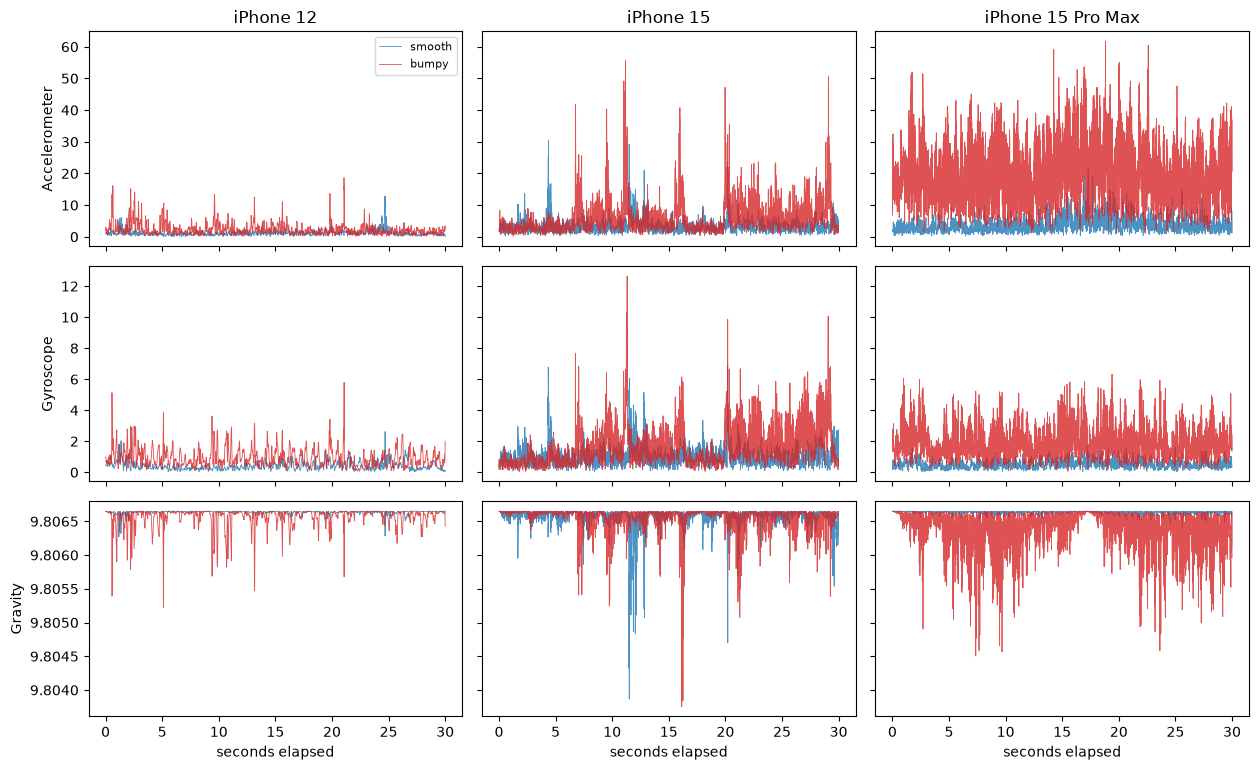

In [490]:
import glob

SENSOR_ROWS = {
    "acc": "Accelerometer",
    "gyro": "Gyroscope",
    "g": "Gravity"
}
LABEL_COLORS = {'smooth': 'tab:blue', 'bumpy': 'tab:red'}

def plot_sensor_device_grid(df: pd.DataFrame, seconds=30, per_group=1):
    devices = df['device'].sort_values().unique()

    fig, axes = plt.subplots(len(SENSOR_ROWS), len(devices),
                             figsize=(4.2*len(devices), 2.6*len(SENSOR_ROWS)),
                             sharex=True, sharey='row')       

    for r, (attr, ylab) in enumerate(SENSOR_ROWS.items()):
        for c, device in enumerate(devices):
            ax = axes[r, c]
            for label, color in LABEL_COLORS.items():
                # Get all rows with this device, this attribute and this label

                picks = df[(df["device"] == device) & (df["label"] == label)].groupby("measurement_id")
                for i, (key, g) in enumerate(picks):
                    if i >= per_group:
                        break
                  
                    g = g[g["seconds_elapsed"] <= seconds]
                    ax.plot(g["seconds_elapsed"], g[f"{attr}_mag"], color=color, linewidth=0.6, alpha=0.8,
                            label=label if (r == 0 and c == 0 and i == 0) else None)
                    
            if r == 0: ax.set_title(device)
            if c == 0: ax.set_ylabel(ylab)
            if r == len(SENSOR_ROWS)-1: ax.set_xlabel('seconds elapsed')
    axes[0, 0].legend(loc='upper right', fontsize=8)
    fig.tight_layout()
    return fig, axes

def plot_magnitude_variations_per_device(df: pd.DataFrame):
    agg = dict()
    for attr in ATTRIBUTE_FILE_MAP.values():
        agg[f"{attr}_std"] = (f"{attr}_mag", "std")
    return df.groupby(["device", "label"]).agg(**agg)



plot_sensor_device_grid(df)
print(plot_magnitude_variations_per_device(df))


**Data Normalization**

After normalization, the magnitude standard deviations are on a common scale
across devices: bumpy recordings now range from 1.24 to 1.30 (previously 1.88
to 13.10) and smooth from 0.36 to 0.58 (previously 0.82 to 3.70). Crucially,
the two classes no longer overlap across devices, meaning the loudest smooth
recording (0.58) now sits below the quietest bumpy one (1.24), whereas before
normalization a smooth recording on the iPhone 15 Pro Max (3.70) read louder
than a bumpy one on the iPhone 12 (1.88). The within-device ordering is
preserved, so the device effect has been removed without erasing the label
signal.

                           acc_std     g_std  gyro_std
device            label                               
iPhone 12         bumpy   1.137800  1.246538  1.111137
                  smooth  0.494379  0.135043  0.391760
iPhone 15         bumpy   1.178791  1.281336  1.140073
                  smooth  0.476332  0.470549  0.586012
iPhone 15 Pro Max bumpy   1.151721  1.299047  1.065219
                  smooth  0.325269  0.129098  0.291757


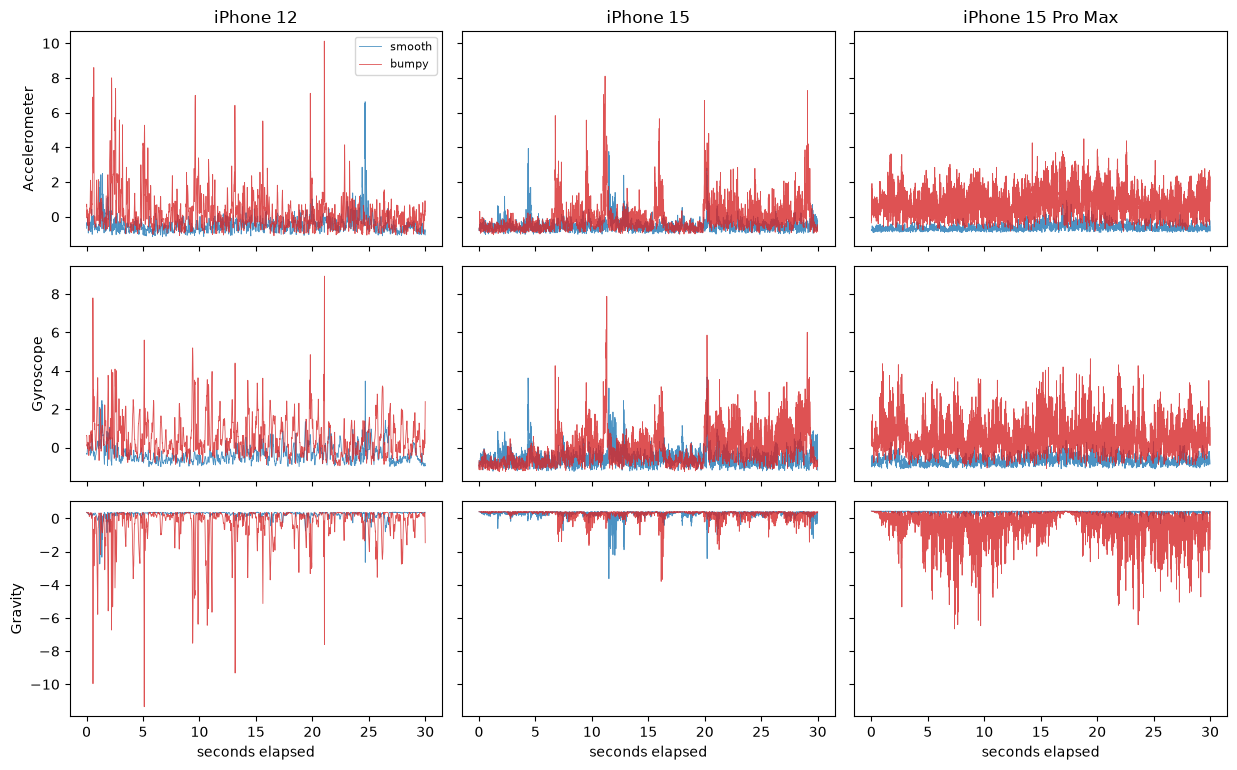

In [492]:
FEATURE_COLUMNS =  [ 
    "acc_mag",
    "gyro_mag",
    "g_mag",
]
def normalize_per_device(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df[FEATURE_COLUMNS] =  df.groupby("device")[FEATURE_COLUMNS].transform(lambda s: (s - s.mean()) / s.std())

    return df

df_norm = normalize_per_device(df)
plot_sensor_device_grid(df_norm)
print(plot_magnitude_variations_per_device(df_norm))